# Multi-Hazard Risk Modeling and Sendai Framework Indicators

This notebook performs comprehensive risk modeling including:
- Sendai Framework indicator calculations
- Hazard exposure assessment
- Vulnerability analysis
- Multi-hazard risk aggregation
- Risk prioritization

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, EXTERNAL_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from src.external_data import ExternalDataFetcher
from src.data_processing import merge_with_population_data, merge_with_gdp_data
from src.risk_metrics import (add_sendai_indicators, calculate_multi_hazard_risk,
                              classify_event_severity, calculate_risk_trends,
                              prioritize_locations_for_intervention)
from src.visualization import plot_sendai_indicators_comparison, create_risk_dashboard

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Processed Disaster Data

In [2]:
data_file = PROCESSED_DATA_DIR / 'disaster_events_processed.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} processed records")
    print(f"Columns: {list(df.columns)}")
else:
    print("Processed data not found. Please run notebook 01 first.")
    df = None

Loaded 30 processed records
Columns: ['serial', 'glide', 'year', 'month', 'day', 'eventname', 'level1', 'level2', 'level3', 'latitude', 'longitude', 'hazardtype', 'deaths', 'injured', 'missing', 'affected', 'displaced', 'housesdestroyed', 'housesdamaged', 'educationcenters', 'healthcenters', 'localvalue', 'usdvalue', 'durationdays', 'eventdescription', 'date', 'season', 'total_affected', 'total_deaths', 'total_houses_affected', 'has_economic_data', 'has_coordinates']


## 2. Fetch External Data (Population and GDP)

**CRITICAL STEP:** This fetches population and GDP data from World Bank API to enable calculation of normalized Sendai Framework indicators.

In [3]:
if df is not None:
    print("Fetching external data from World Bank API...")
    print("This may take a few minutes on first run (data will be cached)\n")
    
    fetcher = ExternalDataFetcher()
    
    external_data = fetcher.fetch_all_external_data()
    
    population_df = external_data['population']
    gdp_df = external_data['gdp']
    
    print(f"\n✓ Population data: {len(population_df)} records")
    print(f"  Countries: {population_df['country'].nunique()}")
    print(f"  Year range: {population_df['year'].min()} - {population_df['year'].max()}")
    
    print(f"\n✓ GDP data: {len(gdp_df)} records")
    print(f"  Countries: {gdp_df['country'].nunique()}")
    print(f"  Year range: {gdp_df['year'].min()} - {gdp_df['year'].max()}")
    
    population_df.to_csv(EXTERNAL_DATA_DIR / 'population_data.csv', index=False)
    gdp_df.to_csv(EXTERNAL_DATA_DIR / 'gdp_data.csv', index=False)
    print("\n✓ External data saved to data/external/")

2026-05-23 09:12:25,530 - INFO - External data fetcher initialized. Cache dir: D:\Projects\sendai-multi-hazard-risk-modeling\data\external
2026-05-23 09:12:25,534 - INFO - Fetching all external data sources...
2026-05-23 09:12:25,537 - INFO - Loading population data from cache: D:\Projects\sendai-multi-hazard-risk-modeling\data\external\population_all.csv
2026-05-23 09:12:25,544 - INFO - Loading GDP data from cache: D:\Projects\sendai-multi-hazard-risk-modeling\data\external\gdp_all.csv


Fetching external data from World Bank API...
This may take a few minutes on first run (data will be cached)


✓ Population data: 650 records
  Countries: 10
  Year range: 1960 - 2024

✓ GDP data: 619 records
  Countries: 10
  Year range: 1960 - 2024

✓ External data saved to data/external/


## 3. Merge Disaster Data with External Data

In [4]:
if df is not None:
    print("Merging disaster data with population and GDP data...\n")
    
    df_with_pop = merge_with_population_data(df, population_df, country_col='level1')
    print(f"After population merge: {df_with_pop['population'].notna().sum()} records have population data")
    
    df_complete = merge_with_gdp_data(df_with_pop, gdp_df, country_col='level1')
    print(f"After GDP merge: {df_complete['gdp'].notna().sum()} records have GDP data")
    
    print(f"\nData completeness:")
    print(f"  Population: {df_complete['population'].notna().sum() / len(df_complete) * 100:.1f}%")
    print(f"  GDP: {df_complete['gdp'].notna().sum() / len(df_complete) * 100:.1f}%")
    
    df_complete.to_csv(PROCESSED_DATA_DIR / 'disaster_events_with_metadata.csv', index=False)
    print("\n✓ Complete dataset saved")

2026-05-23 09:12:25,614 - INFO - Merging disaster data with population data
2026-05-23 09:12:25,629 - INFO - Merged data: 30 records have population data
2026-05-23 09:12:25,634 - INFO - Merging disaster data with GDP data
2026-05-23 09:12:25,648 - INFO - Merged data: 30 records have GDP data


Merging disaster data with population and GDP data...

After population merge: 30 records have population data
After GDP merge: 30 records have GDP data

Data completeness:
  Population: 100.0%
  GDP: 100.0%

✓ Complete dataset saved


## 4. Calculate Sendai Framework Indicators

### The Power of Normalization

Raw disaster counts don't tell the full story. Two countries with the same number of deaths have vastly different risk profiles if one has 10 million people and the other has 100 million.

**Sendai Framework indicators normalize impacts by:**
- Population (per 100,000 people)
- GDP (as percentage of economic output)

This enables fair comparison and evidence-based prioritization.

In [5]:
if df is not None:
    print("Calculating Sendai Framework indicators...\n")
    
    df_sendai = add_sendai_indicators(df_complete)
    
    sendai_cols = [col for col in df_sendai.columns if col.startswith('sendai_')]
    print(f"✓ Added {len(sendai_cols)} Sendai indicators:\n")
    for col in sendai_cols:
        non_null = df_sendai[col].notna().sum()
        print(f"  - {col}: {non_null} records with data")
    
    df_sendai.to_csv(PROCESSED_DATA_DIR / 'disaster_events_sendai.csv', index=False)
    print("\n✓ Data with Sendai indicators saved")

2026-05-23 09:12:25,693 - INFO - Calculating Sendai Framework indicators


Calculating Sendai Framework indicators...



2026-05-23 09:12:25,723 - INFO - Added 12 Sendai indicators: ['sendai_a1_mortality_rate', 'sendai_a2_deaths', 'sendai_a3_missing', 'sendai_b1_affected_rate', 'sendai_b2_injured', 'sendai_b3_damaged_dwellings', 'sendai_b4_destroyed_dwellings', 'sendai_b5_livelihoods_disrupted', 'sendai_c1_economic_loss_pct_gdp', 'sendai_d1_infrastructure_damage_rate', 'sendai_d2_health_facilities', 'sendai_d3_education_facilities']


✓ Added 12 Sendai indicators:

  - sendai_a1_mortality_rate: 30 records with data
  - sendai_a2_deaths: 30 records with data
  - sendai_a3_missing: 30 records with data
  - sendai_b1_affected_rate: 30 records with data
  - sendai_b2_injured: 30 records with data
  - sendai_b3_damaged_dwellings: 30 records with data
  - sendai_b4_destroyed_dwellings: 30 records with data
  - sendai_b5_livelihoods_disrupted: 30 records with data
  - sendai_c1_economic_loss_pct_gdp: 30 records with data
  - sendai_d1_infrastructure_damage_rate: 30 records with data
  - sendai_d2_health_facilities: 30 records with data
  - sendai_d3_education_facilities: 30 records with data

✓ Data with Sendai indicators saved


## 5. Compare Raw Counts vs Normalized Indicators

**Demonstration: Why Normalization Matters for Ministers**

2026-05-23 09:12:29,652 - INFO - Figure saved to D:\Projects\sendai-multi-hazard-risk-modeling\outputs\figures\05_sendai_comparison.png


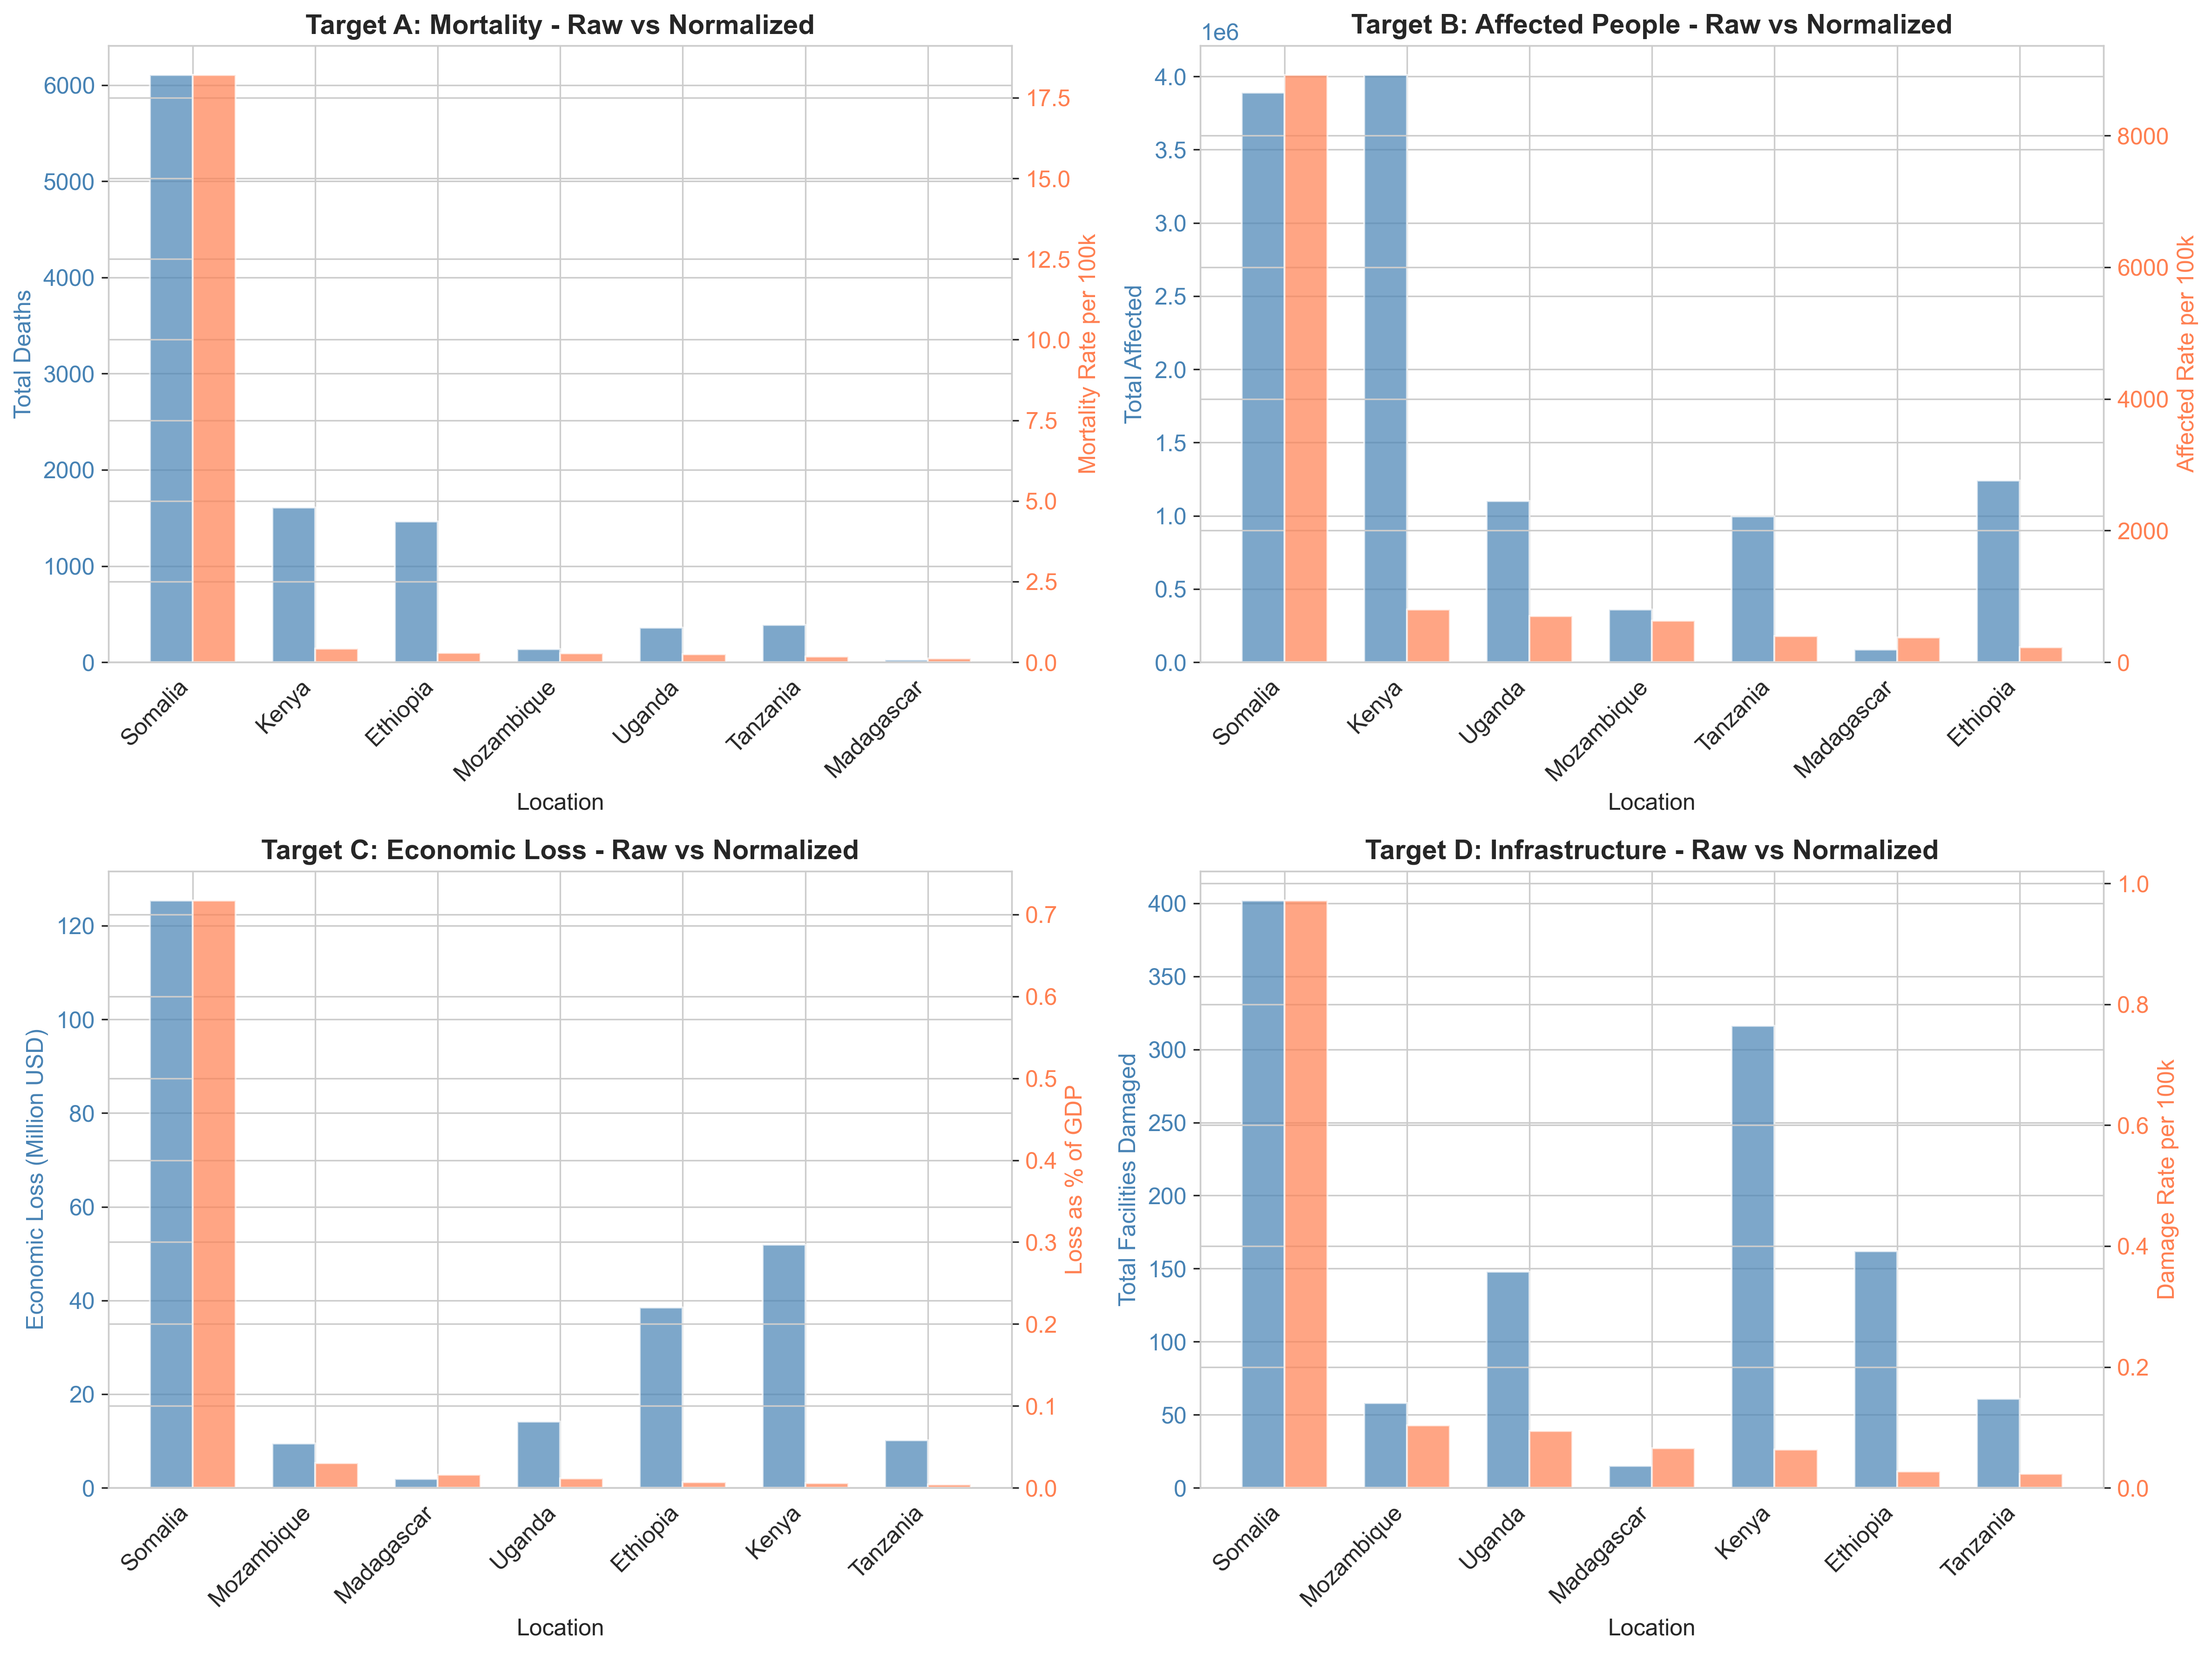


KEY INSIGHT: Raw vs Normalized Comparison

Notice how rankings change when we normalize by population and GDP!

Raw counts favor large countries.
Normalized indicators reveal TRUE RISK per capita.

This is why ministers need complete metadata for evidence-based decisions.


In [6]:
if df is not None and 'sendai_a1_mortality_rate' in df_sendai.columns:
    fig = plot_sendai_indicators_comparison(df_sendai, location_col='level1',
                                            save_path=FIGURES_DIR / '05_sendai_comparison.png')
    plt.show()
    
    print("\n" + "="*80)
    print("KEY INSIGHT: Raw vs Normalized Comparison")
    print("="*80)
    print("\nNotice how rankings change when we normalize by population and GDP!")
    print("\nRaw counts favor large countries.")
    print("Normalized indicators reveal TRUE RISK per capita.")
    print("\nThis is why ministers need complete metadata for evidence-based decisions.")

## 6. Event Severity Classification

2026-05-23 09:12:31,924 - WARNING - Column 'severity_index' not found in DataFrame


Event Severity Distribution:


overall_severity
No Impact    30
Name: count, dtype: int64

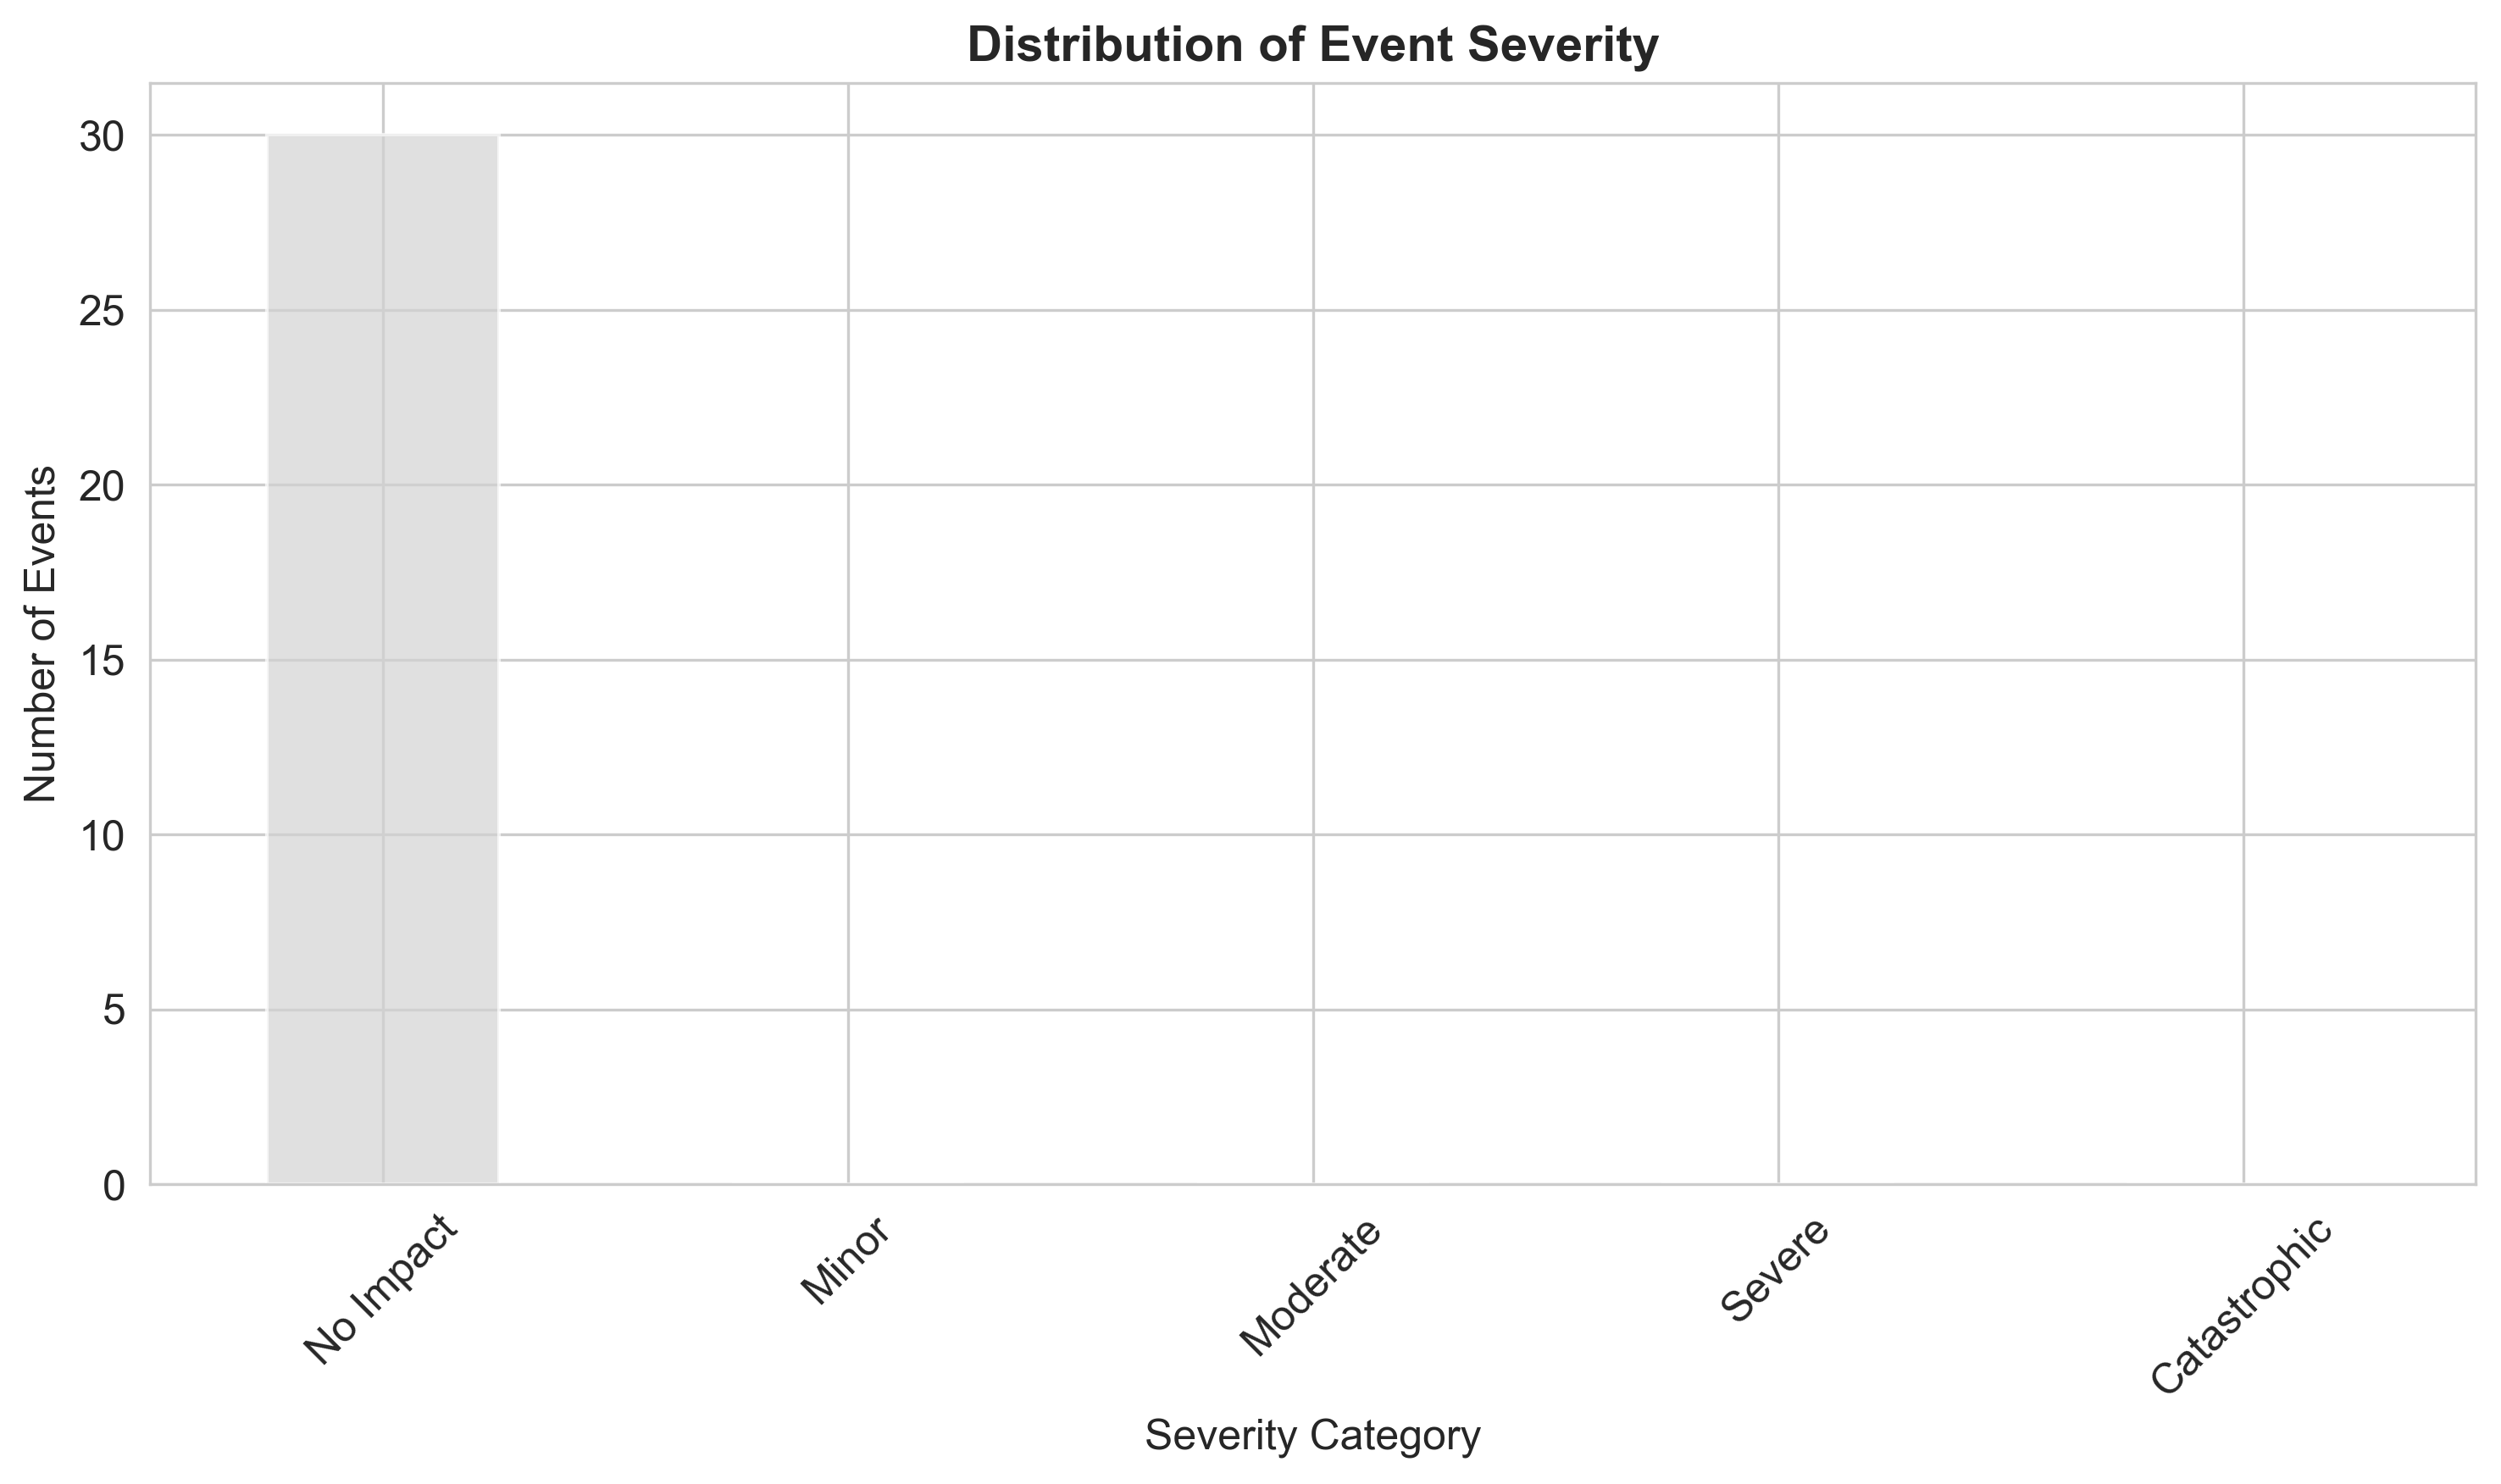

In [7]:
if df is not None:
    df_severity = classify_event_severity(df_sendai)
    
    if 'overall_severity' in df_severity.columns:
        severity_dist = df_severity['overall_severity'].value_counts()
        print("Event Severity Distribution:")
        display(severity_dist)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        severity_order = ['No Impact', 'Minor', 'Moderate', 'Severe', 'Catastrophic']
        severity_dist = severity_dist.reindex(severity_order, fill_value=0)
        colors = ['lightgray', 'yellow', 'orange', 'red', 'darkred']
        severity_dist.plot(kind='bar', ax=ax, color=colors, alpha=0.7)
        ax.set_xlabel('Severity Category', fontsize=12)
        ax.set_ylabel('Number of Events', fontsize=12)
        ax.set_title('Distribution of Event Severity', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '05_severity_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

## 7. Multi-Hazard Risk Assessment

In [8]:
if df is not None:
    print("Calculating multi-hazard risk assessment...\n")
    
    risk_assessment = calculate_multi_hazard_risk(df_sendai, location_col='level2')
    
    print("Top 20 Highest Risk Locations:")
    display(risk_assessment.head(20))
    
    risk_assessment.to_csv(REPORTS_DIR / 'multi_hazard_risk_assessment.csv')
    print("\n✓ Risk assessment saved to outputs/reports/")

2026-05-23 09:12:32,987 - INFO - Calculating multi-hazard risk assessment


Calculating multi-hazard risk assessment...

Top 20 Highest Risk Locations:


,exposure_index,vulnerability_index,risk_score,risk_category,event_count,hazard_diversity
level2,,,,,,
Bay,0.535793,0.861646,0.698720,High,1,1
Lower Shabelle,0.372493,0.718668,0.545580,High,1,1
Western,0.491544,0.037626,0.264585,Medium,2,2
Nairobi,0.513867,0.014087,0.263977,Medium,3,2
Eastern,0.482101,0.042284,0.262192,Medium,2,2
Rift Valley,0.414032,0.021780,0.217906,Low,2,2
Banadir,0.179280,0.233166,0.206223,Low,1,1
Somali,0.150042,0.020032,0.085037,Low,1,1
Northern,0.094753,0.054852,0.074802,Low,1,1



✓ Risk assessment saved to outputs/reports/


## 8. Interactive Risk Dashboard

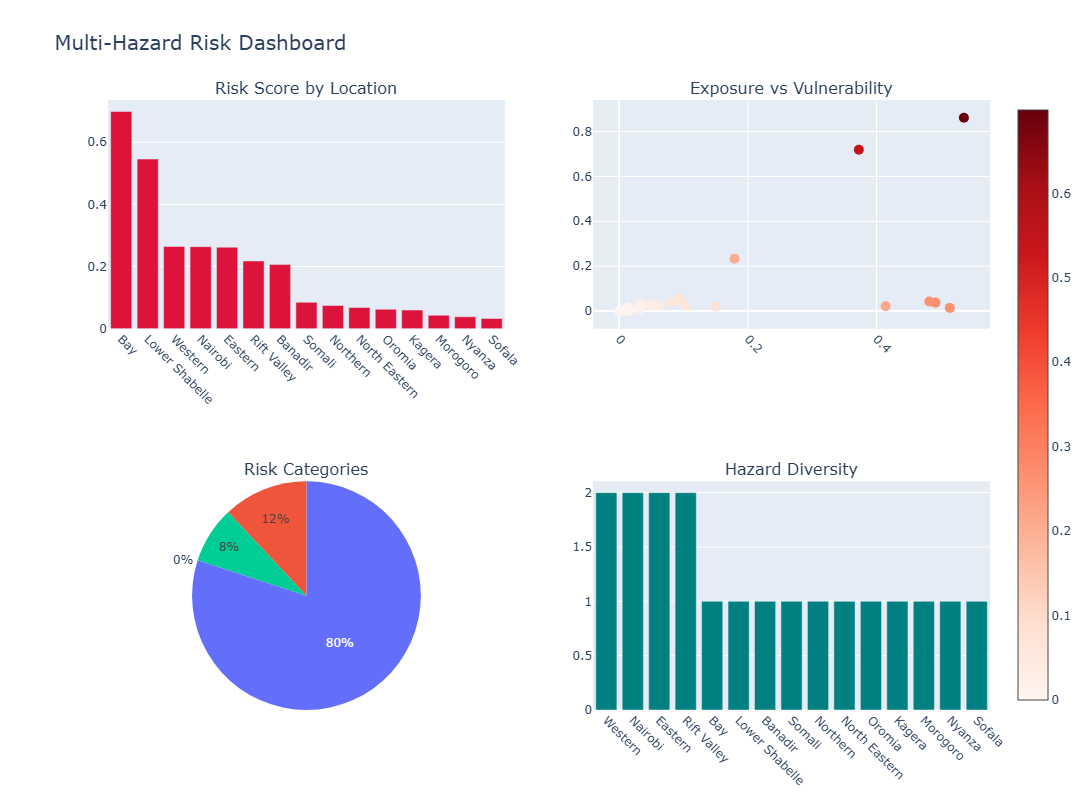


✓ Interactive dashboard saved to outputs/figures/05_risk_dashboard.html


In [9]:
if df is not None:
    fig = create_risk_dashboard(risk_assessment, 
                                title='Multi-Hazard Risk Dashboard')
    fig.show()
    
    fig.write_html(FIGURES_DIR / '05_risk_dashboard.html')
    print("\n✓ Interactive dashboard saved to outputs/figures/05_risk_dashboard.html")

## 9. Priority Locations for Intervention

In [10]:
if df is not None:
    priority_locations = prioritize_locations_for_intervention(risk_assessment, top_n=20)
    
    print("="*80)
    print("PRIORITY LOCATIONS FOR DISASTER RISK REDUCTION INTERVENTIONS")
    print("="*80)
    print("\nTop 20 locations ranked by composite risk score:")
    print("(Higher risk score = higher priority for intervention)\n")
    
    display(priority_locations[['risk_score', 'exposure_index', 'vulnerability_index', 
                                'risk_category', 'event_count', 'hazard_diversity']])
    
    priority_locations.to_csv(REPORTS_DIR / 'priority_locations.csv')
    print("\n✓ Priority locations saved to outputs/reports/")

PRIORITY LOCATIONS FOR DISASTER RISK REDUCTION INTERVENTIONS

Top 20 locations ranked by composite risk score:
(Higher risk score = higher priority for intervention)



,risk_score,exposure_index,vulnerability_index,risk_category,event_count,hazard_diversity
level2,,,,,,
Bay,0.698720,0.535793,0.861646,High,1,1
Lower Shabelle,0.545580,0.372493,0.718668,High,1,1
Western,0.264585,0.491544,0.037626,Medium,2,2
Nairobi,0.263977,0.513867,0.014087,Medium,3,2
Eastern,0.262192,0.482101,0.042284,Medium,2,2
Rift Valley,0.217906,0.414032,0.021780,Low,2,2
Banadir,0.206223,0.179280,0.233166,Low,1,1
Somali,0.085037,0.150042,0.020032,Low,1,1
Northern,0.074802,0.094753,0.054852,Low,1,1



✓ Priority locations saved to outputs/reports/


## 10. Risk Trends Over Time

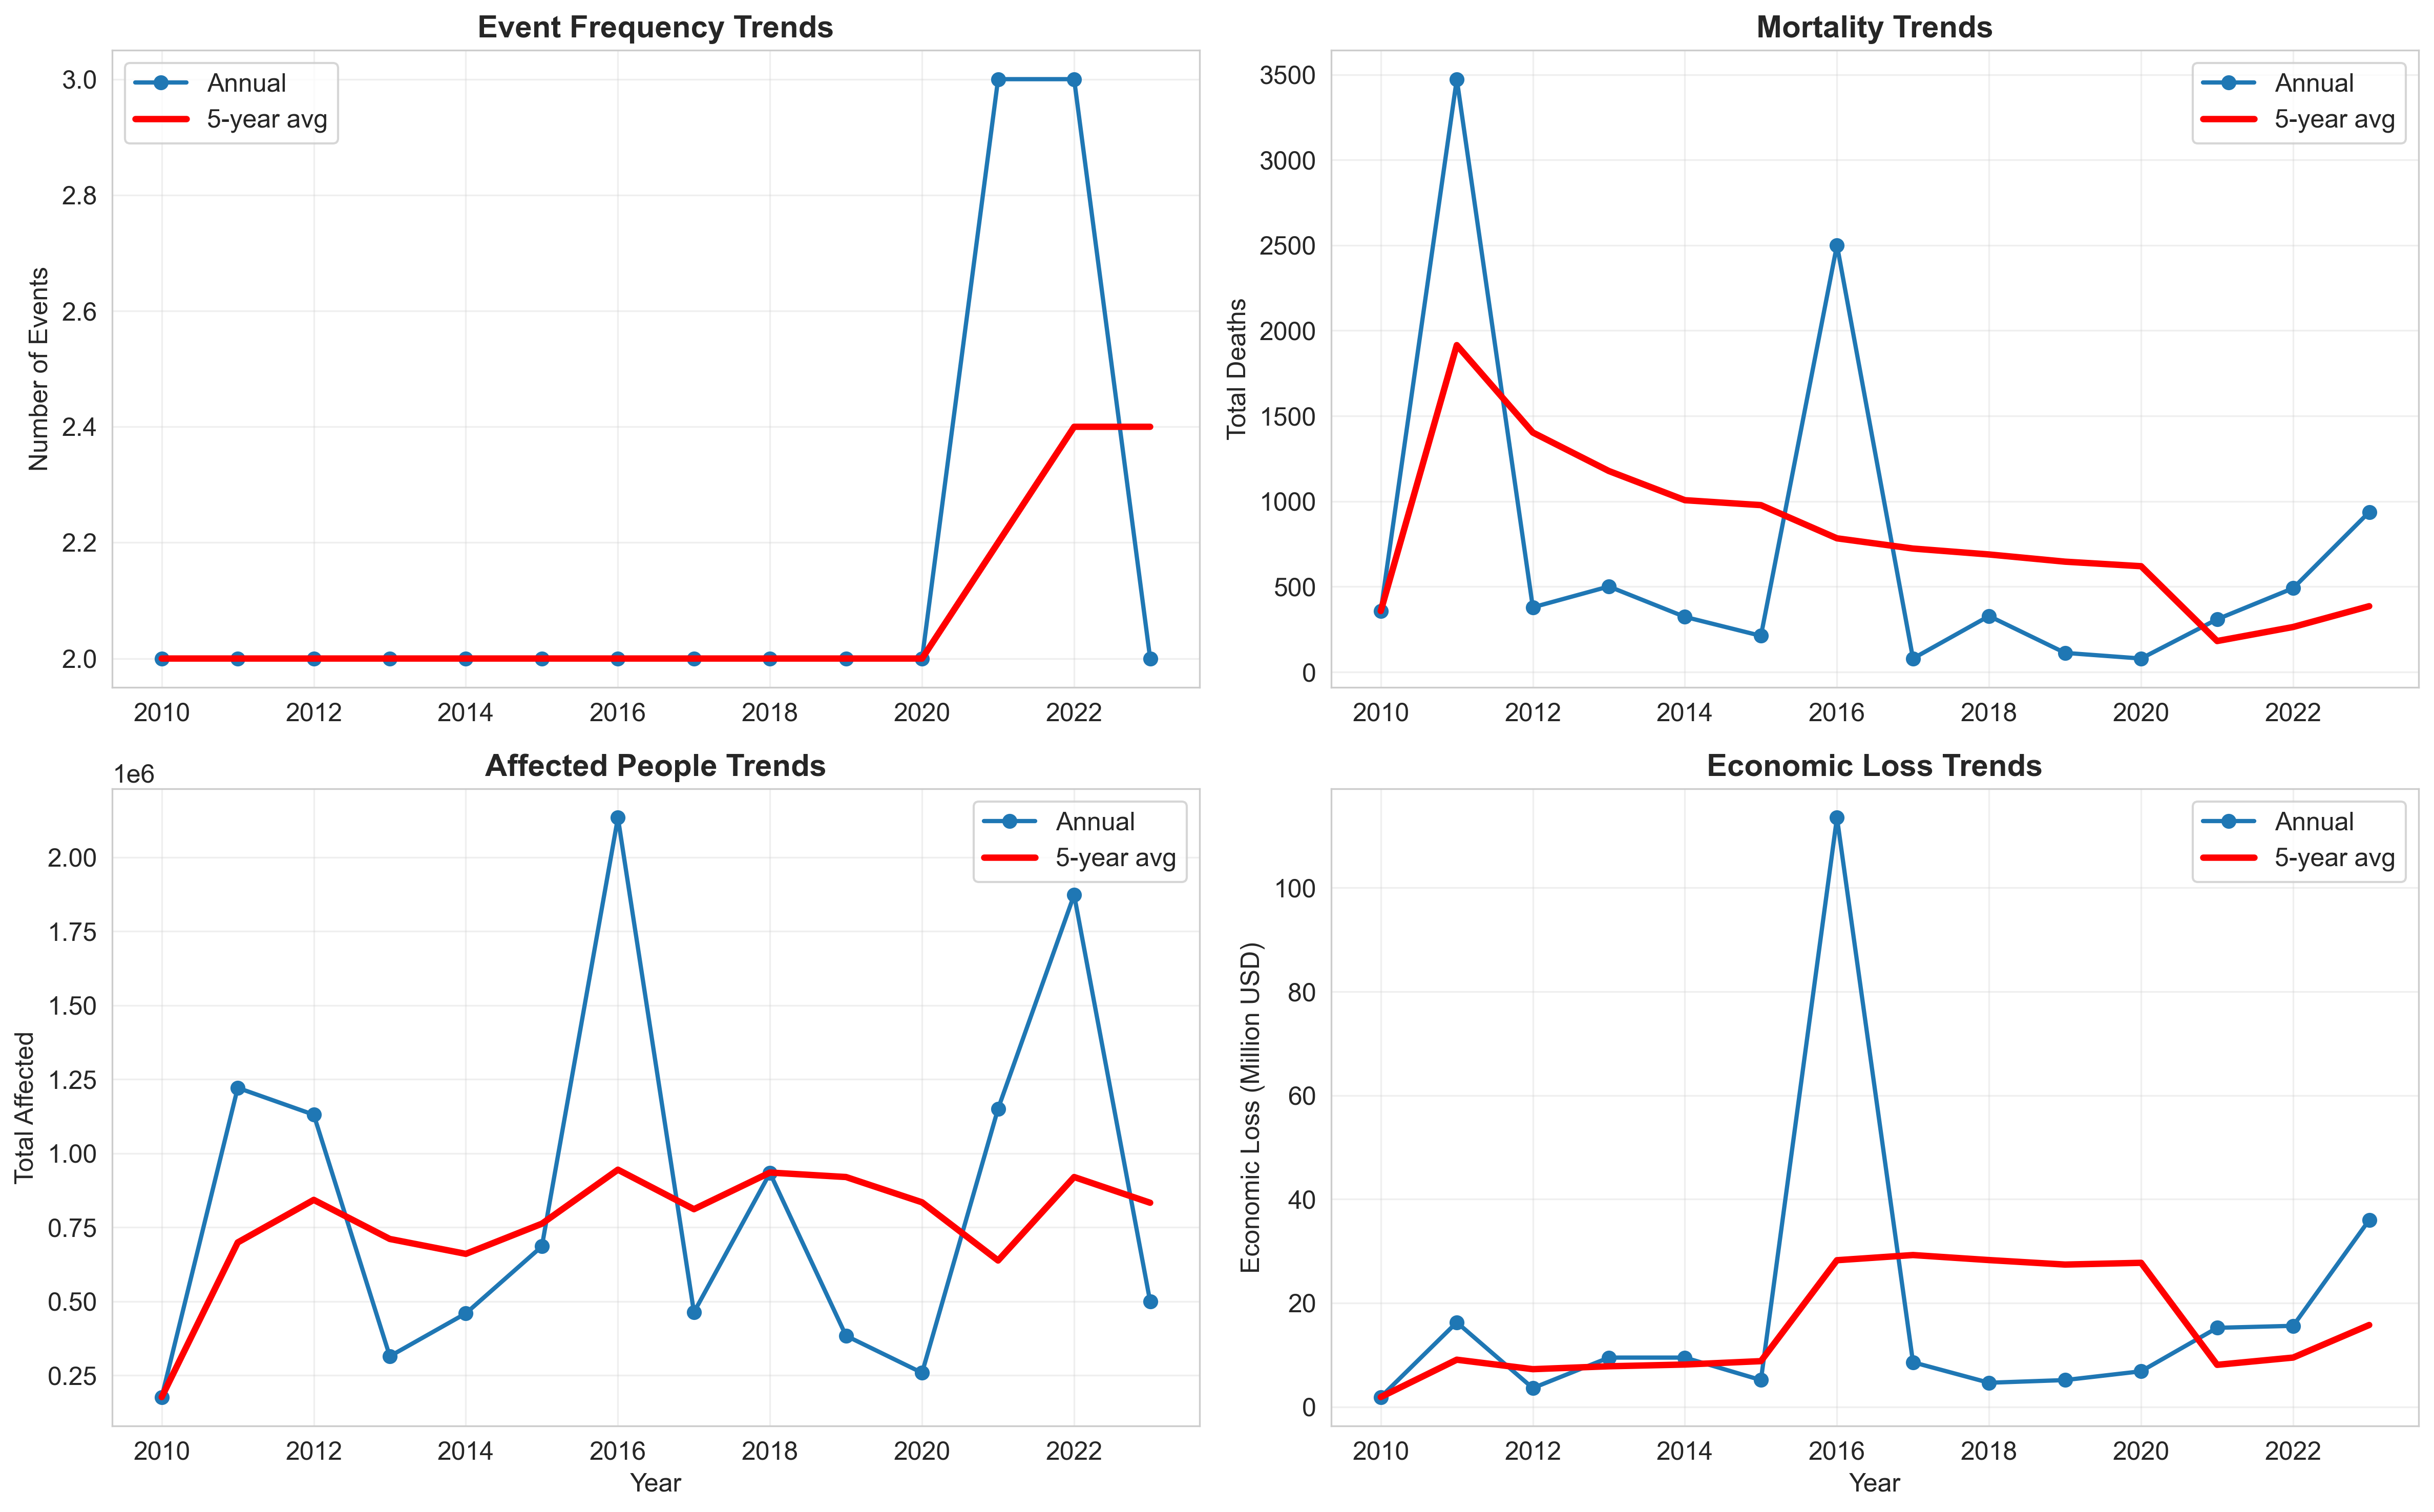

In [11]:
if df is not None:
    risk_trends = calculate_risk_trends(df_sendai, window_years=5)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    if 'event_count' in risk_trends.columns:
        axes[0, 0].plot(risk_trends.index, risk_trends['event_count'], 
                       marker='o', linewidth=2, label='Annual')
        if 'event_count_rolling_avg' in risk_trends.columns:
            axes[0, 0].plot(risk_trends.index, risk_trends['event_count_rolling_avg'],
                           linewidth=3, label='5-year avg', color='red')
        axes[0, 0].set_title('Event Frequency Trends', fontweight='bold')
        axes[0, 0].set_ylabel('Number of Events')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    if 'total_deaths' in risk_trends.columns:
        axes[0, 1].plot(risk_trends.index, risk_trends['total_deaths'],
                       marker='o', linewidth=2, label='Annual')
        if 'total_deaths_rolling_avg' in risk_trends.columns:
            axes[0, 1].plot(risk_trends.index, risk_trends['total_deaths_rolling_avg'],
                           linewidth=3, label='5-year avg', color='red')
        axes[0, 1].set_title('Mortality Trends', fontweight='bold')
        axes[0, 1].set_ylabel('Total Deaths')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    if 'total_affected' in risk_trends.columns:
        axes[1, 0].plot(risk_trends.index, risk_trends['total_affected'],
                       marker='o', linewidth=2, label='Annual')
        if 'total_affected_rolling_avg' in risk_trends.columns:
            axes[1, 0].plot(risk_trends.index, risk_trends['total_affected_rolling_avg'],
                           linewidth=3, label='5-year avg', color='red')
        axes[1, 0].set_title('Affected People Trends', fontweight='bold')
        axes[1, 0].set_ylabel('Total Affected')
        axes[1, 0].set_xlabel('Year')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    if 'total_economic_loss' in risk_trends.columns:
        axes[1, 1].plot(risk_trends.index, risk_trends['total_economic_loss']/1e6,
                       marker='o', linewidth=2, label='Annual')
        if 'total_economic_loss_rolling_avg' in risk_trends.columns:
            axes[1, 1].plot(risk_trends.index, risk_trends['total_economic_loss_rolling_avg']/1e6,
                           linewidth=3, label='5-year avg', color='red')
        axes[1, 1].set_title('Economic Loss Trends', fontweight='bold')
        axes[1, 1].set_ylabel('Economic Loss (Million USD)')
        axes[1, 1].set_xlabel('Year')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_risk_trends.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. Summary Report

In [12]:
if df is not None:
    print("="*80)
    print("MULTI-HAZARD RISK MODELING SUMMARY")
    print("="*80)
    
    print(f"\n📊 Dataset Overview:")
    print(f"   - Total events analyzed: {len(df_sendai):,}")
    print(f"   - Events with population data: {df_sendai['population'].notna().sum():,}")
    print(f"   - Events with GDP data: {df_sendai['gdp'].notna().sum():,}")
    
    print(f"\n🎯 Sendai Framework Indicators:")
    if 'sendai_a1_mortality_rate' in df_sendai.columns:
        avg_mortality = df_sendai['sendai_a1_mortality_rate'].mean()
        print(f"   - Average mortality rate: {avg_mortality:.2f} per 100k population")
    if 'sendai_b1_affected_rate' in df_sendai.columns:
        avg_affected = df_sendai['sendai_b1_affected_rate'].mean()
        print(f"   - Average affected rate: {avg_affected:.2f} per 100k population")
    if 'sendai_c1_economic_loss_pct_gdp' in df_sendai.columns:
        avg_econ = df_sendai['sendai_c1_economic_loss_pct_gdp'].mean()
        print(f"   - Average economic loss: {avg_econ:.3f}% of GDP")
    
    print(f"\n🚨 Risk Assessment:")
    print(f"   - Locations assessed: {len(risk_assessment)}")
    high_risk = risk_assessment[risk_assessment['risk_category'] == 'Very High']
    print(f"   - Very High risk locations: {len(high_risk)}")
    print(f"   - Top priority location: {priority_locations.index[0]}")
    
    print(f"\n📈 Outputs Generated:")
    print("   - Multi-hazard risk assessment report")
    print("   - Priority locations for intervention")
    print("   - Interactive risk dashboard")
    print("   - Sendai Framework indicator visualizations")
    
    print(f"\n✅ Next Steps:")
    print("   1. Review use case demonstrations (financing, preparedness, etc.)")
    print("   2. Explore interactive dashboard")
    print("   3. Use priority locations for resource allocation planning")
    print("   4. Share findings with decision-makers")

MULTI-HAZARD RISK MODELING SUMMARY

📊 Dataset Overview:
   - Total events analyzed: 30
   - Events with population data: 30
   - Events with GDP data: 30

🎯 Sendai Framework Indicators:
   - Average mortality rate: 2.09 per 100k population
   - Average affected rate: 1410.65 per 100k population
   - Average economic loss: 0.080% of GDP

🚨 Risk Assessment:
   - Locations assessed: 25
   - Very High risk locations: 0
   - Top priority location: Bay

📈 Outputs Generated:
   - Multi-hazard risk assessment report
   - Priority locations for intervention
   - Interactive risk dashboard
   - Sendai Framework indicator visualizations

✅ Next Steps:
   1. Review use case demonstrations (financing, preparedness, etc.)
   2. Explore interactive dashboard
   3. Use priority locations for resource allocation planning
   4. Share findings with decision-makers
